<a href="https://colab.research.google.com/github/isamadafridi/Human-Emotion-CNN/blob/main/Human_Emotion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Management**

# Data Downloading

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d muhammadhananasghar/human-emotions-datasethes

Dataset URL: https://www.kaggle.com/datasets/muhammadhananasghar/human-emotions-datasethes
License(s): unknown
human-emotions-datasethes.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip /content/human-emotions-datasethes.zip -d /content/sample_data

Archive:  /content/human-emotions-datasethes.zip
replace /content/sample_data/Emotions Dataset/Emotions Dataset/test/angry/101071.jpg_rotation_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

# Libraries

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPool2D, Dense, BatchNormalization, Dropout, Flatten, GlobalAveragePooling2D, Rescaling, Resizing, Activation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.metrics import Accuracy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau



In [ ]:
CONFIGURATION = {
    "CLASS_NAMES" : ['angry', 'happy', 'nothing', 'sad'],
    "NUM_CLASSES" : 4,
    "BATCH_SIZE" : 32,
    "IM_SIZE" : 224,
    "N_FILTERS" : 32,
    "K_SIZE" : 3,
    "N_STRIDES" : 1,
    "REGULARIZATION_RATE": 0.001,
    "POOL_SIZE": 2,
    "DROPOUT_RATE" :0.2,
    "N_DENSE_1" :64,
    "N_DENSE_2" : 128,
    "N_DENSE_3" : 256,
    "MOMENTUM" : 0.9,
    "EPSILON" : 0.001


}

# Data Loading

In [ ]:
train_directory = "/content/sample_data/EmotionsDataset_Splitted/data/train"
val_directory = "/content/sample_data/EmotionsDataset_Splitted/data/test"

In [ ]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_directory,
    labels='inferred',
    label_mode='categorical',
    class_names=CONFIGURATION['CLASS_NAMES'],
    color_mode='rgb',
    batch_size=CONFIGURATION['BATCH_SIZE'],
    image_size=(CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE']),
    shuffle=True,
    seed=99,

)

Found 3152 files belonging to 4 classes.


In [ ]:
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    val_directory,
    labels='inferred',
    label_mode='categorical',
    class_names=CONFIGURATION['CLASS_NAMES'],
    color_mode='rgb',
    batch_size=1,  # CONFIGURATION['BATCH_SIZE'],
    image_size=(CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE']),
    shuffle=True,
    seed=99,

)

Found 788 files belonging to 4 classes.


In [ ]:
val_unbatched = validation_dataset.unbatch()

In [ ]:
val_unbatched = val_unbatched.shuffle(1000, seed=42)

In [ ]:
val_size = tf.data.experimental.cardinality(val_unbatched).numpy()

test_size = int(0.3 * val_size)
new_val_size = val_size - test_size

In [ ]:
new_val = val_unbatched.take(new_val_size)
test_dataset = val_unbatched.skip(new_val_size)

In [ ]:
val_dataset = new_val.batch(CONFIGURATION['BATCH_SIZE'])
test_dataset = test_dataset.batch(CONFIGURATION['BATCH_SIZE'])

# Dataset Visualization

In [ ]:
import numpy as np

all_labels = []

for images, labels in train_dataset:
    all_labels.extend(np.argmax(labels.numpy(), axis=1))

all_labels = np.array(all_labels)

np.unique(all_labels, return_counts=True)

(array([0, 1, 2, 3]), array([850, 830, 874, 598]))

In [ ]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32, 4)


In [ ]:
for images, labels in val_dataset.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32, 4)


In [ ]:
for images, labels in test_dataset.take(1):
    print(images.shape)
    print(labels.shape)

Meaning:\
32 → batch size\
256,256 → image size\
3 → channels (RGB)\
4 → number of classes\

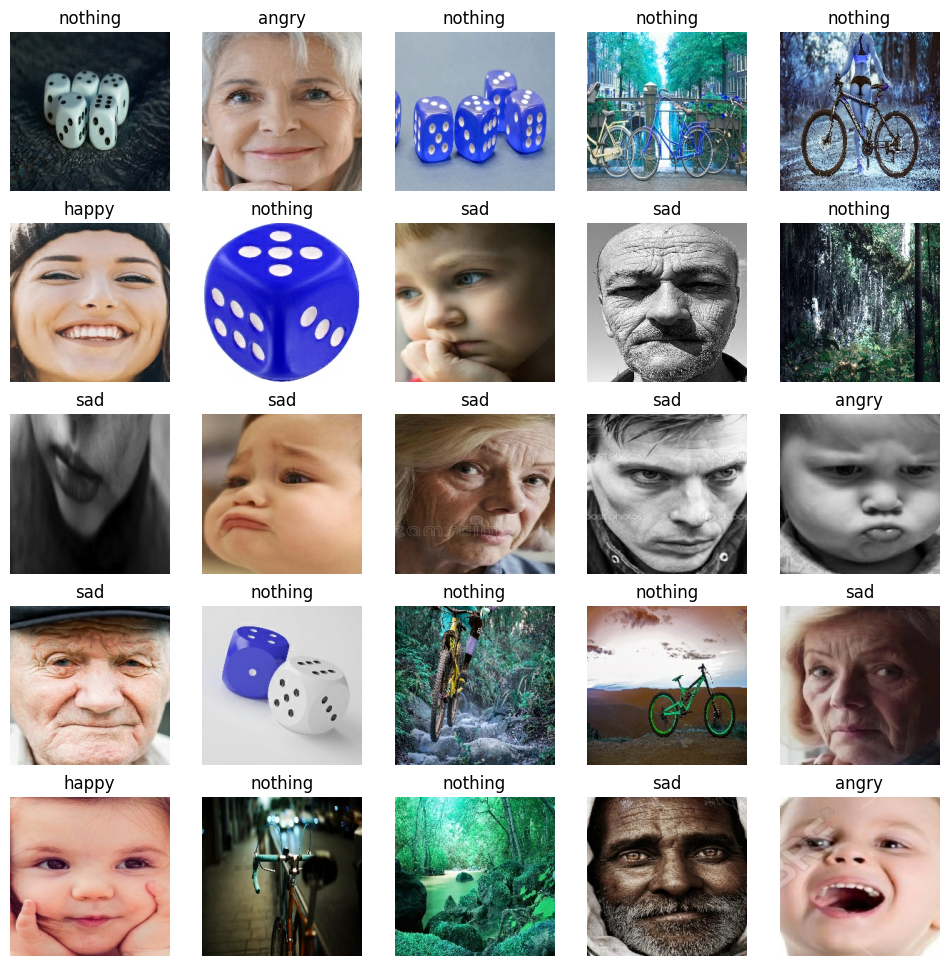

In [ ]:
plt.figure(figsize=(12,12))
for images, labels in train_dataset.take(1):
  for i in range(25):
    ax = plt.subplot(5,5, i+1)
    plt.imshow(images[i]/255.)
    plt.title(CONFIGURATION['CLASS_NAMES'][tf.argmax(labels[i], axis = 0).numpy()])
    # plt.imshow(tf.cast(images[i], tf.uint8))
    plt.axis('OFF')

# Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.GaussianNoise(0.05),

])

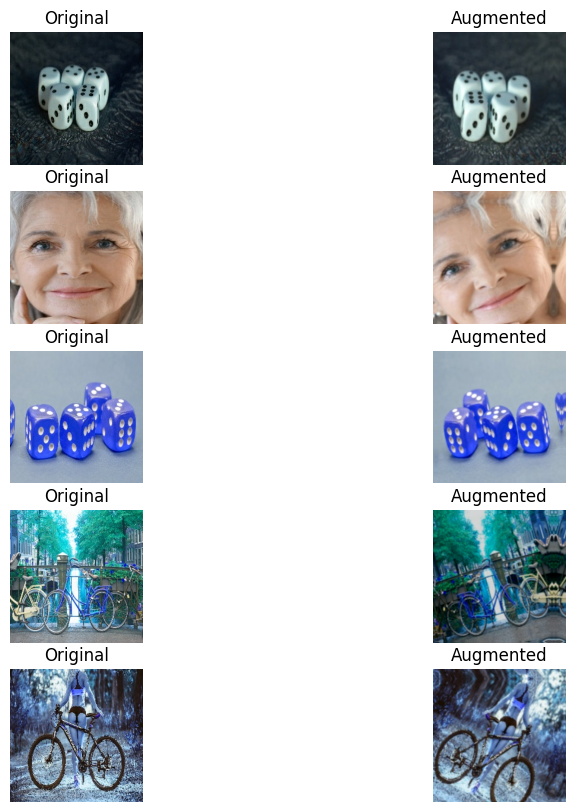

In [ ]:
plt.figure(figsize=(10, 10))

for i in range(5):
    # Original
    ax = plt.subplot(5, 2, 2*i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title("Original")
    plt.axis("off")

    # Augmented
    augmented = data_augmentation(images)
    ax = plt.subplot(3, 4, 2*i + 2)
    plt.imshow(augmented[i].numpy().astype("uint8"))
    plt.title("Augmented")
    plt.axis("off")

plt.show()

# Dataset Preparation

In [ ]:
resize_rescale_layers = tf.keras.Sequential([
       Resizing(CONFIGURATION["IM_SIZE"], CONFIGURATION["IM_SIZE"]),
       Rescaling(1./255),
])

# LeNET-5 Model

In [ ]:
lenet_model = tf.keras.Sequential(
    [
    InputLayer(input_shape = (CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE'], 3), ),

    resize_rescale_layers,

    # 🔥 Data Augmentation
    data_augmentation,


    Conv2D(filters = CONFIGURATION["N_FILTERS"] , kernel_size = CONFIGURATION["K_SIZE"], strides = CONFIGURATION["N_STRIDES"] , padding='same',
          use_bias=False,kernel_regularizer = l2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(momentum=0.9, epsilon=0.001),
    Activation('relu'),
    MaxPool2D (pool_size = CONFIGURATION["POOL_SIZE"], strides= CONFIGURATION["N_STRIDES"]*2),
    # Dropout(rate = CONFIGURATION["DROPOUT_RATE"] ),


    Conv2D(filters = CONFIGURATION["N_FILTERS"]*2, kernel_size = CONFIGURATION["K_SIZE"], strides=CONFIGURATION["N_STRIDES"], padding='same',
          use_bias=False, kernel_regularizer = l2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(momentum=0.9, epsilon=0.001),
    Activation('relu'),
    MaxPool2D (pool_size = CONFIGURATION["POOL_SIZE"], strides= CONFIGURATION["N_STRIDES"]*2),
    # Dropout(rate = CONFIGURATION["DROPOUT_RATE"] ),


    Conv2D(filters = CONFIGURATION["N_FILTERS"]*4 , kernel_size = CONFIGURATION["K_SIZE"], strides = CONFIGURATION["N_STRIDES"] , padding='same',
          use_bias=False,kernel_regularizer = l2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(momentum=0.9, epsilon=0.001),
    Activation('relu'),
    MaxPool2D (pool_size = CONFIGURATION["POOL_SIZE"], strides= CONFIGURATION["N_STRIDES"]*2),
    Dropout(rate = CONFIGURATION["DROPOUT_RATE"]),

    Conv2D(filters = CONFIGURATION["N_FILTERS"]*6, kernel_size = CONFIGURATION["K_SIZE"], strides=CONFIGURATION["N_STRIDES"], padding='same',
          use_bias=False, kernel_regularizer = l2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(momentum=0.9, epsilon=0.001),
    Activation('relu'),
    MaxPool2D (pool_size = CONFIGURATION["POOL_SIZE"], strides= CONFIGURATION["N_STRIDES"]*2),
    Dropout(rate = CONFIGURATION["DROPOUT_RATE"]),

    Flatten(),
    # GlobalAveragePooling2D(),

    Dense( CONFIGURATION["N_DENSE_1"], use_bias=False, kernel_regularizer = l2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(momentum=0.9, epsilon=0.001),
    Activation('relu'),
    Dropout(rate = CONFIGURATION["DROPOUT_RATE"]+0.2),

    Dense( CONFIGURATION['N_DENSE_2'], use_bias=False, kernel_regularizer = l2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(momentum=0.9, epsilon=0.001),
    Activation('relu'),
    Dropout(rate = CONFIGURATION["DROPOUT_RATE"]+0.2),

    Dense( CONFIGURATION['N_DENSE_3'], use_bias=False, kernel_regularizer = l2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(momentum=0.9, epsilon=0.001),
    Activation('relu'),
    Dropout(rate = CONFIGURATION["DROPOUT_RATE"]+0.2),

    Dense(CONFIGURATION["NUM_CLASSES"], activation = "softmax"),

])

# lenet_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


# AlexNet

In [ ]:
# import tensorflow as tf
# from tensorflow.keras import layers, models
# def build_alexnet(input_shape=(224, 224, 3), num_classes=4):

#     model = models.Sequential()

#     # 🔹 Input + Preprocessing
#     model.add(layers.Input(shape=input_shape))
#     model.add(layers.Resizing(224, 224))
#     model.add(layers.Rescaling(1./255))

#     # 🔥 Data Augmentation (HERE)
#     model.add(data_augmentation)


#     # 🔹 Conv Layer 1
#     model.add(layers.Conv2D(96, (11,11), strides=4, activation='relu'))
#     model.add(layers.BatchNormalization())
#     model.add(layers.MaxPooling2D(pool_size=(3,3), strides=2))

#     # 🔹 Conv Layer 2
#     model.add(layers.Conv2D(256, (5,5), padding='same', activation='relu'))
#     model.add(layers.BatchNormalization())
#     model.add(layers.MaxPooling2D(pool_size=(3,3), strides=2))

#     # 🔹 Conv Layer 3
#     model.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))

#     # 🔹 Conv Layer 4
#     model.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))

#     # 🔹 Conv Layer 5
#     model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
#     model.add(layers.MaxPooling2D(pool_size=(3,3), strides=2))

#     # 🔹 Fully Connected Layers
#     model.add(layers.Flatten())

#     model.add(layers.Dense(4096, activation='relu'))
#     model.add(layers.Dropout(0.5))

#     model.add(layers.Dense(4096, activation='relu'))
#     model.add(layers.Dropout(0.5))

#     model.add(layers.Dense(num_classes, activation='softmax'))

#     return model

# model = build_alexnet()

# model.summary()

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
        ),

    ModelCheckpoint(
      "/content/drive/MyDrive/Best_Model/best_model.keras",
      monitor='val_accuracy',
      save_best_only=True ),

    ReduceLROnPlateau(
      monitor='val_loss',
      factor=0.3,
      patience=3,
      min_lr=1e-6)
]

In [ ]:
optimizer = tf.keras.optimizers.Adam()

lenet_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics = ['accuracy'])
# loss = 'sparse_categorical_crossentropy'

In [ ]:
history = lenet_model.fit( train_dataset, validation_data=val_dataset, epochs = 50, callbacks=callbacks)

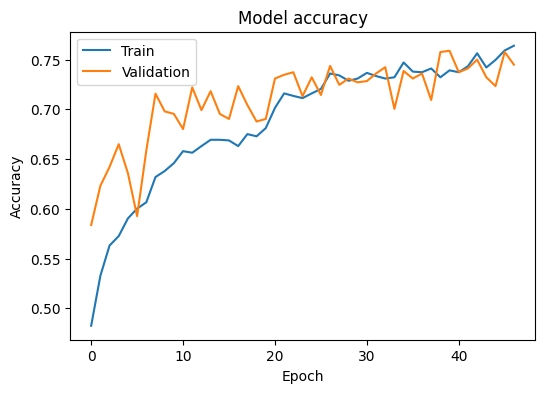

In [ ]:
plt.figure(figsize=(6, 4))

# Plot training & validation accuracy values
# plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

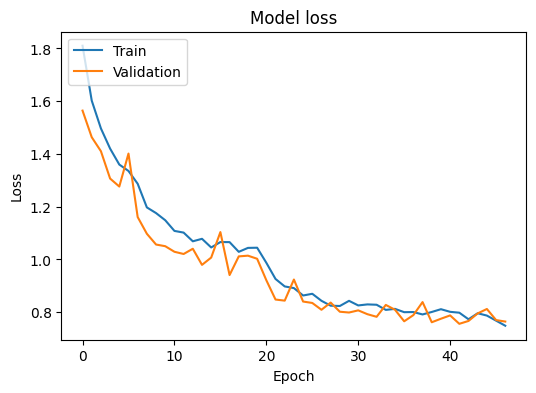

In [ ]:
plt.figure(figsize=(6, 4))

# Plot training & validation loss values
# plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

# Pre Trained Model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
base_model = tf.keras.applications.Xception(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

In [ ]:
base_model.trainable = False

model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu',kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),


    layers.Dense(4, activation='softmax')  # your emotion classes
])



In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
        ),

    ModelCheckpoint(
      "/content/drive/MyDrive/Best_Model/best_model.keras",
      monitor='val_accuracy',
      save_best_only=True ),

    ReduceLROnPlateau(
      monitor='val_loss',
      factor=0.3,
      patience=3,
      min_lr=1e-6)
]

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.topkcategoricalaccuracy(k=)]
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 35s 213ms/step - accuracy: 0.3626 - loss: 2.3756 - val_accuracy: 0.5292 - val_loss: 1.7558 - learning_rate: 1.0000e-04
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.4876 - loss: 1.9653 - val_accuracy: 0.5571 - val_loss: 1.6136 - learning_rate: 1.0000e-04
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.5060 - loss: 1.8746 - val_accuracy: 0.5990 - val_loss: 1.5726 - learning_rate: 1.0000e-04
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.5568 - loss: 1.7487 - val_accuracy: 0.6129 - val_loss: 1.5081 - learning_rate: 1.0000e-04
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.5755 - loss: 1.6774 - val_accuracy: 0.6066 - val_loss: 1.5151 - learning_rate: 1.0000e-04
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.5847 - loss: 1.6477 - val_accuracy: 0.6168 - val_loss: 1.4742 - learning_rate: 1.0000e-04
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.

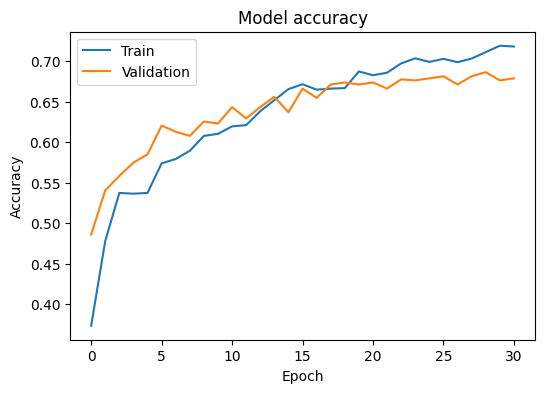

In [ ]:
plt.figure(figsize=(6, 4))

# Plot training & validation accuracy values
# plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

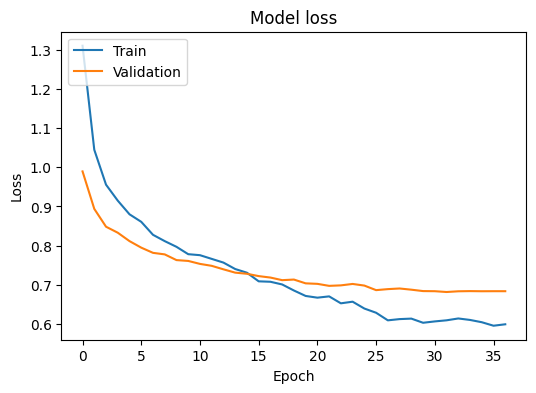

In [ ]:
plt.figure(figsize=(6, 4))

# Plot training & validation loss values
# plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

# Testing

In [ ]:
test_loss, test_acc = model.evaluate(val_dataset)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6650 - loss: 0.6850
Test Accuracy: 0.6649746298789978
Test Loss: 0.6849613189697266


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print(cm)

NameError: name 'y_true' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

NameError: name 'cm' is not defined

<Figure size 600x500 with 0 Axes>

In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.58      0.63       213
           1       0.74      0.71      0.72       207
           2       0.98      1.00      0.99       219
           3       0.51      0.64      0.57       149

    accuracy                           0.74       788
   macro avg       0.73      0.73      0.73       788
weighted avg       0.75      0.74      0.74       788



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Save Model

In [ ]:
model.save("/content/drive/MyDrive/Best_Model/my_model.keras")

# Load Model

In [ ]:
import tensorflow as tf
path = '/content/drive/MyDrive/Best_Model/my_model.keras'
model = tf.keras.models.load_model(path)  # or .keras

In [ ]:
loss, accuracy = model.evaluate(train_dataset)

print("Loss:", loss)
print("Accuracy:", accuracy)

99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.7992 - loss: 0.5243
Loss: 0.5242907404899597
Accuracy: 0.7991751432418823


# Test with Unseen Data

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "/content/download (7).jpg"  # your new image path

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)  # batch dimension
img_array = img_array / 255.0  # same rescaling as training

pred = model.predict(img_array)

class_id = np.argmax(pred)
print("Predicted Class:", class_id)
print("Confidence:", pred)

CLASS_NAMES = ['angry', 'happy', 'nothing', 'sad']

print("Predicted Emotion:", CLASS_NAMES[class_id])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Predicted Class: 2
Confidence: [[6.0959272e-05 4.6544224e-05 9.9978876e-01 1.0375585e-04]]
Predicted Emotion: nothing
